# 11i — Net-zero stock-level results (`net_zero10a-c`)

`chap11_net_zero10a.m` re-solves the `net_zero6`/`net_zero7`-style
tracking-error-minimization problem at real MSCI World stock level, at
every point along **four** decarbonization-pathway glide paths (IEA,
NZAOA, CTB, PAB, from `11f`'s `pathway_benchmarks()`) simultaneously, for
each of 4 emission scopes ($\mathcal{SC}_1,\mathcal{SC}_{1-2},
\mathcal{SC}^{up}_{1-3},\mathcal{SC}_{1-3}$). **This compute step is
blocked**: it needs `data/MSCI_WORD_2015_2023` (the stock-level
holdings/emissions dataset, missing entirely from the archive) *and*
`Results/Decarbonization1` (a precomputed pathway-target file, also not
present).

`net_zero10b` and `net_zero10c`, however, are pure plotting scripts that
read **precomputed** `Results/chap11_net_zero10a.mat` and
`Results/chap11_net_zero10c.mat` files, both of which *are* shipped in
the archive (the same "blocked compute, buildable plot from real shipped
results" situation as several `11e` scripts) — copied into this repo's
`data/` folder and built faithfully below. There is no producer script
for `chap11_net_zero10c.mat` anywhere in the archive (its `all_results`
struct-array content, and what its 7 entries individually represent,
can't be reconstructed from usage — `net_zero10c.m` itself only ever
reads index 6 of 7); it's used here exactly as the source does, as an
opaque precomputed input.

In [1]:
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
from csaps import csaps

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


def packr(x, y):
    # Drop any (x, y) pair where either is NaN, matching MATLAB's packr.
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    return x[mask], y[mask]


def smoothing_spline_curve(x_fit, y_fit, x_grid, p, scale=1.0):
    # Port of fit(x_fit,y_fit,'smoothingspline','SmoothingParam',p) + missex
    # masking beyond the fitted range. Unlike 11e's near-p=1 (near-
    # interpolating) cases, net_zero10b/10c use p=0.9 -- genuine smoothing,
    # not near-interpolation -- so this uses the csaps package directly
    # (confirmed in 11f/11g to be a parameter-compatible port of the same
    # underlying algorithm/parameterization as fit's SmoothingParam) rather
    # than 11e's natural-cubic-spline approximation.
    x_fit, y_fit = packr(x_fit, y_fit)
    x_grid = np.asarray(x_grid, dtype=float)
    y = scale * csaps(x_fit, y_fit, x_grid, smooth=p)
    y = np.where(x_grid > x_fit[-1], np.nan, y)
    return y


PATHWAY_LABELS = ["IEA", "NZAOA", "CTB", "PAB"]
PATHWAY_COLORS = ["tab:blue", "tab:red", "tab:green", "tab:purple"]
PATHWAY_STYLES = ["-", "--", ":", "-."]
SCOPE_TITLES = [r"$\mathcal{SC}_1$", r"$\mathcal{SC}_{1-2}$",
                r"$\mathcal{SC}^{up}_{1-3}$", r"$\mathcal{SC}_{1-3}$"]


def plot_scope_grid(x, y_by_scope, ylabel, ylims):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    for ax, y, title, ylim in zip(axes.flat, y_by_scope, SCOPE_TITLES, ylims):
        for i in range(4):
            ax.plot(x, y[:, i], PATHWAY_STYLES[i], color=PATHWAY_COLORS[i],
                     lw=2, label=PATHWAY_LABELS[i])
        ax.set_xlim(2020, 2035)
        ax.set_xticks(range(2020, 2036, 5))
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.set_title(title)
        ax.set_xlabel("$t$")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
    axes.flat[-1].legend(labels=PATHWAY_LABELS[::-1], handles=axes.flat[-1].get_lines()[::-1],
                          fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()

## 1. Tracking error vs. time, by scope (`net_zero10b`)

$\sigma(w\mid b)$ (bps) along each of the 4 pathway glide paths, for each
of the 4 emission scopes -- fit with a genuine smoothing spline
($p=1-\text{tol}=0.9$, not the near-interpolating case used in `11e`)
through the 30 yearly `net_zero10a` re-optimization points (2021-2050),
evaluated on a fine 0.1-year grid and masked (NaN) beyond the last point
each scope/pathway pair actually reached before the optimizer hit
infeasibility (matching the source's `retcode>=1` early-break, visible
here as `NaN`s in the raw `.mat` data itself for the higher scopes).

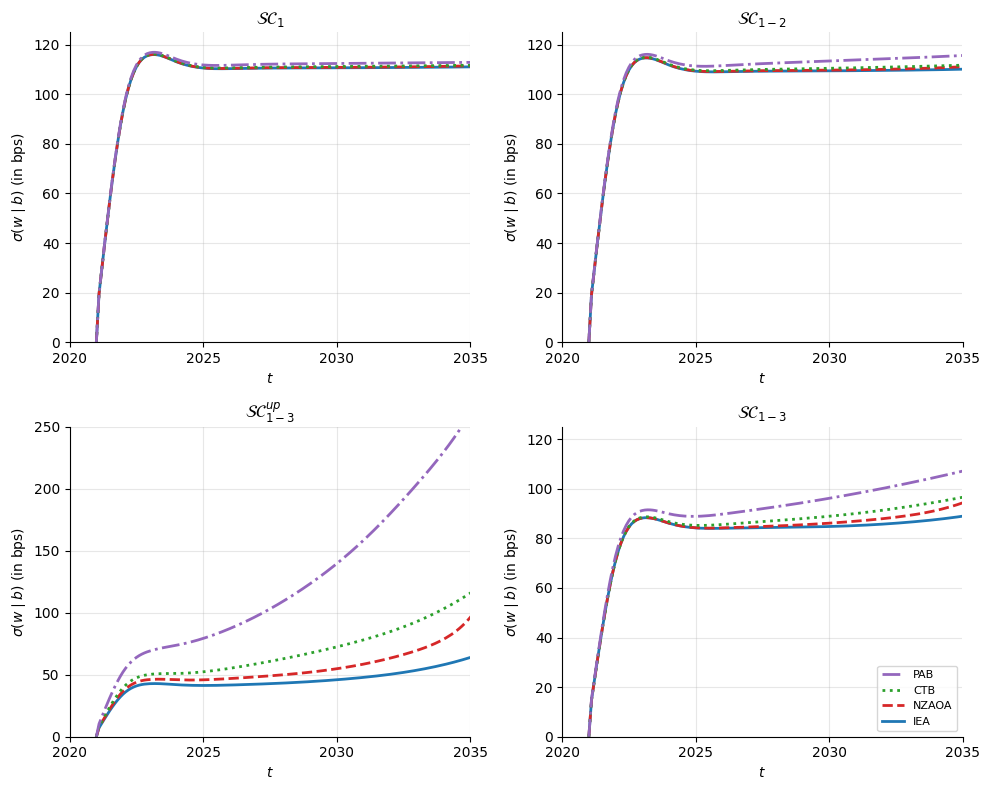

In [2]:
mat10a = sio.loadmat(f"{DATA_DIR}/chap11_net_zero10a.mat")
data_t = mat10a["all_t"].ravel().astype(float)
data_Risk = mat10a["all_sigma_x"]  # (nT=30, nPathway=4, nScope=4)

x_grid = np.arange(2021, 2050 + 1e-9, 0.1)
tol = 1e-1

y_by_scope_10b = []
for scope in range(4):
    data_Risk_Scope = data_Risk[:, :, scope]  # (nT, nPathway)
    y = np.zeros((len(x_grid), 4))
    for iter_ in range(4):
        y[:, iter_] = smoothing_spline_curve(data_t, data_Risk_Scope[:, iter_], x_grid,
                                              p=1 - tol, scale=1e4)
    y[0, :] = 0.0
    y_by_scope_10b.append(y)

plot_scope_grid(x_grid, y_by_scope_10b, r"$\sigma(w\mid b)$ (in bps)",
                 ylims=[(0, 125), (0, 125), (0, 250), (0, 125)])

## 2. A second stock-level risk metric vs. time, by scope (`net_zero10c`)

Same 4-scope grid, this time reading `Results/chap11_net_zero10c.mat`'s
precomputed `all_results(6)` entry directly (index 5 in 0-based Python;
the source picks this fixed index with no documented reason and no
producer script to check it against). Values are scaled by 100 and
halved (`y = y/2`, exactly as the source does, with no further
explanation of the metric beyond its axis label
$\mathcal{D}(w\mid b)$ -- reproduced literally rather than guessed at).

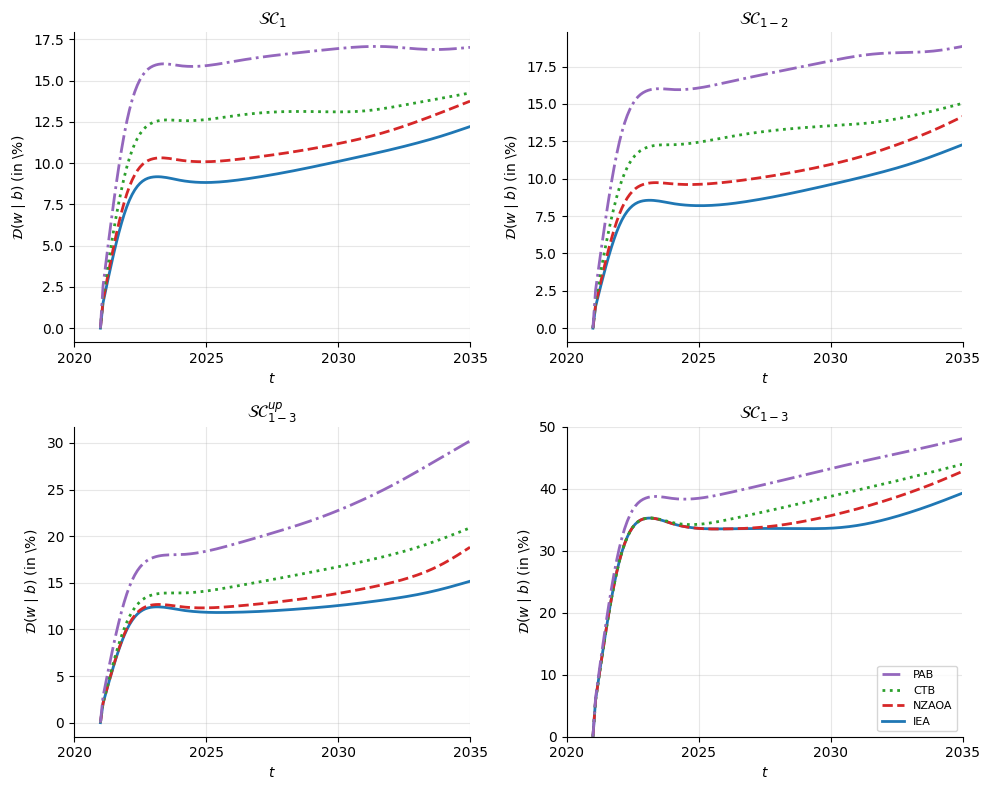

In [3]:
mat10c = sio.loadmat(f"{DATA_DIR}/chap11_net_zero10c.mat", struct_as_record=False, squeeze_me=True)
all_results = mat10c["all_results"]
entry = all_results[5]  # iter = 6 in the (1-indexed) source
data_t_c = entry.dates[:, 0, 0].astype(float)
data_D = entry.data  # (nT=15, nScope=4, nPathway=4)

y_by_scope_10c = []
for scope in range(4):
    data_D_Scope = data_D[:, scope, :]  # (nT, nPathway)
    y = np.zeros((len(x_grid), 4))
    for iter_ in range(4):
        y[:, iter_] = smoothing_spline_curve(data_t_c, data_D_Scope[:, iter_], x_grid,
                                              p=1 - tol, scale=100.0)
    y[0, :] = 0.0
    y = y / 2
    y_by_scope_10c.append(y)

plot_scope_grid(x_grid, y_by_scope_10c, r"$\mathcal{D}(w\mid b)$ (in \%)",
                 ylims=[None, None, None, (0, 50)])

## Blocked scripts (`net_zero10a` and beyond)

- **`net_zero10a`**: the actual stock-level re-optimization compute step.
  Blocked on two independent missing inputs: `data/MSCI_WORD_2015_2023`
  (stock-level MSCI World holdings/emissions panel, entirely absent from
  the archive) and `Results/Decarbonization1` (a precomputed pathway
  target file feeding its `Reduction`/`t` glide-path grid, also absent).
  Its shipped `Results/chap11_net_zero10a.mat` output (used above) proves
  the compute step ran successfully against the original author's private
  data at some point -- but the raw inputs needed to reproduce it aren't
  in this archive.
- **`net_zero10c`**'s own compute step (whatever produced `all_results`,
  a struct array with 7 unlabeled entries) has no `.m` source in the
  archive at all -- only the precomputed `.mat` output and the plotting
  consumer script survive.